# §4.11 Real Non-Stationary Time Series — ETTh1 (Electricity Transformer Temperature)

**실험 목적**: Synthetic 환경이 아닌 실제 물리적 시계열에서 Nomadic Full의
transition dynamics control이 유효한지 검증.
특히 ΔH (entropy differentiation) signature가 실제 regime transition에서도 나타나는지 확인.

**데이터**: ETTh1.csv (2016-07-01 ~ 2018-06-26, 시간 단위, 17420 rows)
- 출처: Electricity Transformer Temperature dataset (ETT)
- 특징: HUFL, HULL, MUFL, MULL, LUFL, LULL (부하), OT (오일 온도)

**Regime 정의**: OT 7-day rolling std 기반 3분위 분류 (Bitcoin 실험과 방법론 일관성 유지)
- Regime 0 (Low Vol):  roll_std < 33rd pct — 안정적 저변동 구간 (겨울)
- Regime 1 (Mid Vol):  33rd ≤ roll_std < 67th pct — 중변동 전환 구간 (봄/가을)
- Regime 2 (High Vol): roll_std ≥ 67th pct — 고변동 구간 (여름)

**Bitcoin 대비 구조적 우위**:
- 평균 stable run length: ~85 스텝 (Bitcoin: ~1 스텝)
- Regime 전환 횟수: 202회 (명확한 경계 존재)
- 예측 대상(OT)이 물리적 시스템 → near-random 노이즈 지배 없음

**입력 (input_dim=7)**: HUFL, HULL, MUFL, MULL, LUFL, LULL, OT (정규화)
**예측 목표**: OT_{t+1} (1-step ahead)

**비교 모델**: Standard MoE vs Nomadic Full (3 seeds)
**Seeds**: 42, 123, 456 | **Epochs**: 220 | **GPU**: L4

In [1]:
# ============================================================
# STEP 0: 환경 확인
# ============================================================
import torch
print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

PyTorch: 2.10.0+cu128
CUDA available: True
GPU: NVIDIA L4
VRAM: 23.7 GB


In [2]:
# ============================================================
# STEP 1: Google Drive 마운트 & 데이터 경로 설정
# ============================================================
# --- 방법 A: Google Drive 마운트 ---
# from google.colab import drive
# drive.mount('/content/drive')
# CSV_PATH = '/content/drive/MyDrive/ETTh1.csv'

# --- 방법 B: 직접 업로드 ---
# from google.colab import files
# uploaded = files.upload()  # ETTh1.csv 선택
# CSV_PATH = 'ETTh1.csv'

# --- 방법 C: 경로 직접 지정 ---
CSV_PATH = 'ETTh1.csv'  # 실제 경로로 수정

print(f'CSV_PATH: {CSV_PATH}')

CSV_PATH: ETTh1.csv


In [3]:
# ============================================================
# STEP 2: Imports & Reproducibility
# ============================================================
import os, random, math, time
from dataclasses import dataclass
from typing import Dict, List, Tuple, Optional

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib
import matplotlib.pyplot as plt

matplotlib.rcParams['figure.dpi'] = 120

def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Using device: {DEVICE}')

Using device: cuda


In [4]:
# ============================================================
# STEP 3: Config
# ============================================================
@dataclass
class Config:
    seed: int = 42
    device: str = DEVICE

    # data
    input_dim: int = 7           # HUFL, HULL, MUFL, MULL, LUFL, LULL, OT
    output_dim: int = 1          # OT_{t+1}
    num_regimes: int = 3
    roll_window: int = 24 * 7    # 7일 rolling std window

    # model — synthetic과 동일
    hidden_dim: int = 64
    num_experts: int = 3
    gate_hidden_dim: int = 64
    temperature: float = 0.60

    # training
    epochs: int = 220
    lr: float = 2e-3
    weight_decay: float = 1e-5
    batch_size: int = 64
    train_ratio: float = 0.70
    val_ratio: float = 0.15

    # hybrid delta — synthetic과 동일
    ema_decay: float = 0.95
    err_baseline_momentum: float = 0.85
    w_env: float = 1.0
    w_err: float = 2.0

    # loss weights — synthetic과 동일
    alpha_dogma: float = 0.04
    beta_nomad: float = 0.05
    beta_phi: float = 0.02
    gamma_diversity: float = 0.08
    lambda_sep: float = 0.08
    lambda_cons: float = 0.03
    lambda_load: float = 0.03
    tau_k_min: int = 3
    tau_k_penalty: float = 0.05

    # dynamic tau
    use_dynamic_tau: bool = True
    tau_min: float = 2.0
    tau_max: float = 8.0
    tau_var_scale: float = 6.0
    tau_var_window: int = 8

    # phi / switching
    phi_scale_env: float = 1.0
    phi_scale_err: float = 1.5
    phi_scale_explain: float = 1.5
    phi_scale_gap: float = 0.8

    temp_stable: float = 0.35
    temp_transition: float = 0.90

    use_hard_switch: bool = True
    phi_hard_threshold: float = 0.30

    # policy
    policy_hidden_dim: int = 64
    policy_mix_weight: float = 0.25
    policy_weight_stay: float = 0.20
    policy_weight_target: float = 0.20
    policy_weight_mode: float = 0.10
    policy_switch_threshold: float = 0.50

    save_dir: str = 'outputs_etth1'

SEEDS = [42, 123, 456]
print('Config loaded.')
print(f'input_dim={Config().input_dim}, Seeds: {SEEDS}')

Config loaded.
input_dim=7, Seeds: [42, 123, 456]


In [5]:
# ============================================================
# STEP 4: Data Preprocessing — ETTh1 → Regime-labeled Tensor
# ============================================================
def load_etth1_data(csv_path: str, cfg: Config):
    """
    ETTh1.csv → (X, Y, R, dates)

    입력 X: [HUFL, HULL, MUFL, MULL, LUFL, LULL, OT]_t  (정규화)
    목표 Y: OT_{t+1}
    레이블 R: OT 7-day rolling std 3분위 기반 (0/1/2)

    Regime:
    - 0 (Low Vol):  roll_std < 33rd pct  → 저변동 안정 (주로 겨울)
    - 1 (Mid Vol):  33rd ≤ roll_std < 67th pct  → 중변동 전환 (봄/가을)
    - 2 (High Vol): roll_std ≥ 67th pct  → 고변동 (여름)

    Bitcoin 실험과 동일한 방법론: rolling volatility 3분위 분류
    """
    df = pd.read_csv(csv_path)
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date').reset_index(drop=True)

    feature_cols = ['HUFL', 'HULL', 'MUFL', 'MULL', 'LUFL', 'LULL', 'OT']

    # 7-day rolling std (OT 기준)
    df['roll_std'] = df['OT'].rolling(cfg.roll_window).std()
    df = df.dropna(subset=['roll_std']).reset_index(drop=True)

    # target: OT_{t+1}
    df['target'] = df['OT'].shift(-24)
    df = df.dropna(subset=['target']).reset_index(drop=True)

    # Regime 레이블
    n = len(df)
    n_train = int(n * cfg.train_ratio)
    p33 = df['roll_std'].iloc[:n_train].quantile(0.33)
    p67 = df['roll_std'].iloc[:n_train].quantile(0.67)

    df['regime'] = 0
    df.loc[df['roll_std'] >= p33, 'regime'] = 1
    df.loc[df['roll_std'] >= p67, 'regime'] = 2

    print(f'Loaded: {len(df)} rows')
    print(f'Date: {df["date"].iloc[0].date()} → {df["date"].iloc[-1].date()}')
    print(f'Regime dist: { {i: int((df["regime"]==i).sum()) for i in range(3)} }')
    print(f'Vol thresholds: Low<{p33:.4f}, Mid<{p67:.4f}, High≥{p67:.4f}')

    # Regime transition 통계
    R_arr = df['regime'].values
    transitions = sum(1 for i in range(1, len(R_arr)) if R_arr[i] != R_arr[i-1])
    print(f'Regime transitions: {transitions} | Avg stable run: {len(R_arr)/transitions:.1f} steps')

    # 정규화 (train split 기준)
    X_raw = df[feature_cols].values.astype(np.float32)
    Y_raw = df['target'].values.astype(np.float32).reshape(-1, 1)
    R_raw = df['regime'].values.astype(np.int64)
    dates = df['date'].values

    x_mean = X_raw[:n_train].mean(axis=0)
    x_std  = X_raw[:n_train].std(axis=0) + 1e-8
    y_mean = Y_raw[:n_train].mean()
    y_std  = Y_raw[:n_train].std() + 1e-8

    X_norm = (X_raw - x_mean) / x_std
    Y_norm = (Y_raw - y_mean) / y_std

    return X_norm, Y_norm, R_raw, dates, (y_mean, y_std), (x_mean, x_std)


def split_data(X, Y, R, dates, cfg: Config):
    """시계열 순서 유지 split"""
    n = len(X)
    n_train = int(n * cfg.train_ratio)
    n_val   = int(n * cfg.val_ratio)

    def to_tensor(arr, dtype=torch.float32):
        return torch.tensor(arr, dtype=dtype).to(cfg.device)

    splits = {}
    for name, s, e in [('train', 0, n_train),
                        ('val',   n_train, n_train + n_val),
                        ('test',  n_train + n_val, n)]:
        splits[name] = {
            'X': to_tensor(X[s:e]),
            'Y': to_tensor(Y[s:e]),
            'R': to_tensor(R[s:e], dtype=torch.long),
            'dates': dates[s:e],
            'n': e - s,
        }
        rdist = {i: int((R[s:e]==i).sum()) for i in range(3)}
        print(f'{name}: {e-s} rows | Regime dist: {rdist}')
    return splits


def generate_phase_tags(R_tensor, window=2):
    """
    Regime 전환 경계 ±window 스텝을 'transition_X_to_Y',
    나머지를 'stable_X'로 태깅.
    ETTh1은 평균 stable run ~85 스텝이라 window=2도 충분.
    """
    R = R_tensor.cpu().numpy() if isinstance(R_tensor, torch.Tensor) else R_tensor
    n = len(R)
    regime_names = {0: 'LowVol', 1: 'MidVol', 2: 'HighVol'}
    tags = [f'stable_{regime_names[R[i]]}' for i in range(n)]

    for i in range(1, n):
        if R[i] != R[i-1]:
            prev_r = R[i-1]
            next_r = R[i]
            for j in range(max(0, i-window), min(n, i+window+1)):
                tags[j] = f'transition_{regime_names[prev_r]}_to_{regime_names[next_r]}'
    return tags


# 데이터 로드
cfg_data = Config()
os.makedirs(cfg_data.save_dir, exist_ok=True)

X_all, Y_all, R_all, dates_all, y_stats, x_stats = load_etth1_data(CSV_PATH, cfg_data)
splits = split_data(X_all, Y_all, R_all, dates_all, cfg_data)

# test set phase tags (배치 단위)
R_test_np = splits['test']['R'].cpu().numpy()
# 배치 단위 regime (각 배치의 첫 샘플 기준)
batch_size = cfg_data.batch_size
R_test_batched = np.array([R_test_np[i] for i in range(0, len(R_test_np), batch_size)])
test_phase_tags = generate_phase_tags(R_test_batched, window=2)

stable_cnt = sum(1 for t in test_phase_tags if t.startswith('stable_'))
trans_cnt  = sum(1 for t in test_phase_tags if t.startswith('transition_'))
print(f'\nTest phase tags (batch-level): stable={stable_cnt}, transition={trans_cnt}')
print('Data preprocessing complete.')

Loaded: 17229 rows
Date: 2016-07-07 → 2018-06-25
Regime dist: {0: 7938, 1: 4909, 2: 4382}
Vol thresholds: Low<2.3153, Mid<3.0143, High≥3.0143
Regime transitions: 178 | Avg stable run: 96.8 steps
train: 12060 rows | Regime dist: {0: 3980, 1: 4100, 2: 3980}
val: 2584 rows | Regime dist: {0: 2377, 1: 177, 2: 30}
test: 2585 rows | Regime dist: {0: 1581, 1: 632, 2: 372}

Test phase tags (batch-level): stable=9, transition=32
Data preprocessing complete.


In [6]:
# ============================================================
# STEP 5: Model Definitions (param_matched_experiment.ipynb 동일)
# ============================================================
class Expert(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, hidden_dim), nn.Tanh(),
            nn.Linear(hidden_dim, output_dim),
        )
    def forward(self, x): return self.net(x)

class GateNet(nn.Module):
    def __init__(self, input_dim, gate_hidden_dim, num_experts, use_delta=True):
        super().__init__()
        self.use_delta = use_delta
        in_dim = input_dim + 2 if use_delta else input_dim
        self.net = nn.Sequential(
            nn.Linear(in_dim, gate_hidden_dim), nn.ReLU(),
            nn.Linear(gate_hidden_dim, gate_hidden_dim), nn.ReLU(),
            nn.Linear(gate_hidden_dim, num_experts),
        )
    def forward(self, x, delta_hybrid=None, delta_err=None, temperature=1.0):
        gate_input = torch.cat([x, delta_hybrid, delta_err], dim=-1) if self.use_delta else x
        logits = self.net(gate_input)
        return F.softmax(logits / temperature, dim=-1), logits

class PolicyNet(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_experts):
        super().__init__()
        self.shared = nn.Sequential(
            nn.Linear(input_dim + 5, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
        )
        self.stay_switch_head = nn.Linear(hidden_dim, 2)
        self.target_head      = nn.Linear(hidden_dim, num_experts)
        self.mode_head        = nn.Linear(hidden_dim, 2)
    def forward(self, policy_input):
        h = self.shared(policy_input)
        return (F.softmax(self.stay_switch_head(h), dim=-1),
                F.softmax(self.target_head(h),      dim=-1),
                F.softmax(self.mode_head(h),        dim=-1))

class StandardMoE(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_experts, gate_hidden_dim):
        super().__init__()
        self.num_experts = num_experts
        self.experts = nn.ModuleList([Expert(input_dim, hidden_dim, output_dim)
                                      for _ in range(num_experts)])
        self.gate = nn.Sequential(
            nn.Linear(input_dim, gate_hidden_dim), nn.ReLU(),
            nn.Linear(gate_hidden_dim, gate_hidden_dim), nn.ReLU(),
            nn.Linear(gate_hidden_dim, num_experts),
        )
    def forward(self, x):
        logits = self.gate(x)
        gate_probs = F.softmax(logits, dim=-1)
        expert_outputs = torch.stack([e(x) for e in self.experts], dim=1)
        y_hat = (gate_probs.unsqueeze(-1) * expert_outputs).sum(dim=1)
        return y_hat, gate_probs, logits, expert_outputs

class NomadicMoE(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, num_experts,
                 gate_hidden_dim, policy_hidden_dim=64):
        super().__init__()
        self.num_experts = num_experts
        self.experts  = nn.ModuleList([Expert(input_dim, hidden_dim, output_dim)
                                       for _ in range(num_experts)])
        self.gate     = GateNet(input_dim, gate_hidden_dim, num_experts, use_delta=True)
        self.policy   = PolicyNet(input_dim, policy_hidden_dim, num_experts)

    def forward(self, x, delta_hybrid, delta_err, temperature=1.0):
        gate_probs, logits = self.gate(x, delta_hybrid, delta_err, temperature)
        expert_outputs = torch.stack([e(x) for e in self.experts], dim=1)
        y_hat = (gate_probs.unsqueeze(-1) * expert_outputs).sum(dim=1)
        return y_hat, gate_probs, logits, expert_outputs

def count_params(model):
    return sum(p.numel() for p in model.parameters())

_cfg = Config()
_std = StandardMoE(_cfg.input_dim, _cfg.hidden_dim, _cfg.output_dim,
                    _cfg.num_experts, _cfg.gate_hidden_dim)
_nom = NomadicMoE(_cfg.input_dim, _cfg.hidden_dim, _cfg.output_dim,
                   _cfg.num_experts, _cfg.gate_hidden_dim, _cfg.policy_hidden_dim)
print(f'StandardMoE params: {count_params(_std):,}')
print(f'NomadicMoE  params: {count_params(_nom):,}')
print('Model definitions ready.')

StandardMoE params: 19,078
NomadicMoE  params: 24,653
Model definitions ready.


In [7]:
# ============================================================
# STEP 6: Nomadic Signal Utilities (param_matched_experiment.ipynb 동일)
# ============================================================
class HybridDeltaTracker:
    def __init__(self, cfg: Config, device):
        self.cfg = cfg
        self.device = device
        self.reset()

    def reset(self):
        self.prev_x_mean  = None
        self.ema_err      = 0.0
        self.baseline_err = 0.0
        self.var_window   = []

    def compute(self, xb, batch_mse):
        cfg = self.cfg
        x_mean = xb.mean(0)
        de = 0.0 if self.prev_x_mean is None else \
             float((x_mean - self.prev_x_mean).norm(p=2).item())
        self.prev_x_mean = x_mean.detach()

        mse_val = float(batch_mse.item()) if isinstance(batch_mse, torch.Tensor) else float(batch_mse)
        self.ema_err      = cfg.ema_decay * self.ema_err + (1 - cfg.ema_decay) * mse_val
        self.baseline_err = cfg.err_baseline_momentum * self.baseline_err + \
                            (1 - cfg.err_baseline_momentum) * self.ema_err
        derr = float(max(0.0, self.ema_err - self.baseline_err))
        dh   = math.tanh(cfg.w_env * de + cfg.w_err * derr)

        self.var_window.append(de)
        if len(self.var_window) > cfg.tau_var_window:
            self.var_window.pop(0)
        sigma2   = float(np.var(self.var_window)) if len(self.var_window) > 1 else 0.0
        dyn_tau  = cfg.tau_min + (cfg.tau_max - cfg.tau_min) * math.exp(-cfg.tau_var_scale * sigma2)
        dh_t     = torch.full((xb.size(0), 1), dh, device=self.device)
        return dh_t, de, derr, dh, sigma2, dyn_tau


class DwellTimeRegularizer:
    def __init__(self, tau_k_min, penalty):
        self.tau_k_min = tau_k_min
        self.penalty   = penalty
        self.reset()

    def reset(self):
        self.current_expert = None
        self.dwell_count    = 0

    def compute(self, gate_probs, tau_dynamic=None):
        tau = tau_dynamic if tau_dynamic is not None else float(self.tau_k_min)
        top1 = int(gate_probs.argmax(-1).float().mean().round().item())
        if self.current_expert is None or top1 != self.current_expert:
            self.current_expert = top1
            self.dwell_count = 1
        else:
            self.dwell_count += 1
        bonus = self.penalty if self.dwell_count >= tau else 0.0
        return torch.tensor(bonus, dtype=torch.float32, device=gate_probs.device)


def gate_entropy(gate_probs):
    return -(gate_probs * (gate_probs + 1e-8).log()).sum(-1)

def compute_phi_signal(de, derr, expl_err, gap, cfg):
    raw = (cfg.phi_scale_env     * de
           + cfg.phi_scale_err   * derr
           + cfg.phi_scale_explain * float(expl_err.item() if isinstance(expl_err, torch.Tensor) else expl_err)
           + cfg.phi_scale_gap   * float(gap.item()       if isinstance(gap,       torch.Tensor) else gap))
    return torch.tensor(math.tanh(raw), dtype=torch.float32, device=cfg.device)

def compute_adaptive_temperature(phi, cfg):
    p = float(phi.item()) if isinstance(phi, torch.Tensor) else float(phi)
    return cfg.temp_stable + (cfg.temp_transition - cfg.temp_stable) * p

def build_policy_input(xb, delta_hybrid, delta_err_t, phi, sigma2, dyn_tau):
    phi_t = torch.full((xb.size(0), 1), float(phi.item() if isinstance(phi, torch.Tensor) else phi), device=xb.device)
    sig_t = torch.full((xb.size(0), 1), sigma2,  device=xb.device)
    tau_t = torch.full((xb.size(0), 1), dyn_tau, device=xb.device)
    return torch.cat([xb, delta_hybrid, delta_err_t, phi_t, sig_t, tau_t], dim=-1)

def compute_explanation_signals(yb, y_hat, exp_out, gate_probs):
    with torch.no_grad():
        task_loss = F.mse_loss(y_hat, yb)
        per_expert_mse = torch.stack([
            F.mse_loss(exp_out[:, k, :], yb) for k in range(exp_out.size(1))
        ])
        best_mse = per_expert_mse.min()
        top1_mse = per_expert_mse[gate_probs.argmax(-1).float().mean().long()]
        gap = F.relu(top1_mse - best_mse)
    return task_loss, gap

def compute_diversity_loss(expert_outputs):
    K = expert_outputs.size(1)
    loss = 0.0
    for i in range(K):
        for j in range(i+1, K):
            loss -= F.cosine_similarity(expert_outputs[:, i, :],
                                        expert_outputs[:, j, :], dim=-1).mean()
    return loss / max(1, K*(K-1)//2)

def compute_load_balancing_loss(gate_probs):
    return gate_probs.mean(0).var()

def compute_dogma_penalty(gate_probs):
    return (gate_probs.max(-1).values - 1.0 / gate_probs.size(-1)).clamp(min=0).mean()

def compute_nomad_bonus(gate_probs):
    return gate_entropy(gate_probs).mean()

def compute_regime_gate_stats(gate_probs, regime_labels):
    sep_loss  = torch.tensor(0.0, device=gate_probs.device)
    cons_loss = torch.tensor(0.0, device=gate_probs.device)
    unique_r  = regime_labels.unique()
    if len(unique_r) < 2:
        return sep_loss, cons_loss
    regime_means = []
    for r in unique_r:
        mask = (regime_labels == r)
        if mask.sum() > 0:
            regime_means.append(gate_probs[mask].mean(0))
    if len(regime_means) >= 2:
        pairs = 0
        for i in range(len(regime_means)):
            for j in range(i+1, len(regime_means)):
                sep_loss -= F.cosine_similarity(
                    regime_means[i].unsqueeze(0), regime_means[j].unsqueeze(0)).mean()
                pairs += 1
        sep_loss = -sep_loss / max(1, pairs)
    for r in unique_r:
        mask = (regime_labels == r)
        if mask.sum() > 1:
            cons_loss += gate_probs[mask].var(0).mean()
    return sep_loss, cons_loss

def build_policy_targets(yb, exp_out, phi, sigma2, dyn_tau, cfg):
    phi_val  = float(phi.item() if isinstance(phi, torch.Tensor) else phi)
    sw_lbl   = 1 if phi_val > cfg.phi_hard_threshold else 0
    per_expert_mse = torch.stack([
        F.mse_loss(exp_out[:, k, :], yb) for k in range(exp_out.size(1))
    ])
    tgt_lbl  = per_expert_mse.argmin()
    mode_lbl = 1 if (sigma2 < 0.01 and dyn_tau > cfg.tau_min + 1) else 0
    return sw_lbl, tgt_lbl, mode_lbl

print('Signal utilities ready.')

Signal utilities ready.


In [8]:
# ============================================================
# STEP 7: Evaluation Functions
# ============================================================
def regimewise_usage(gate_probs_all, regime_labels_all, num_experts):
    G = gate_probs_all.detach().cpu().numpy() if isinstance(gate_probs_all, torch.Tensor) else gate_probs_all
    R = regime_labels_all.cpu().numpy()       if isinstance(regime_labels_all, torch.Tensor) else regime_labels_all
    return {r: G[R==r].mean(0) for r in range(3) if (R==r).sum() > 0}

def infer_regime_to_expert(usage_dict):
    return {r: int(np.argmax(g)) for r, g in usage_dict.items()}

def compute_switch_latency(regime_seq, top1_seq, r2e):
    latencies = []
    n = len(regime_seq)
    for i in range(1, n):
        if regime_seq[i] != regime_seq[i-1]:
            target = r2e.get(int(regime_seq[i]), -1)
            if target < 0: continue
            for lag in range(1, min(10, n-i)):
                if top1_seq[i+lag] == target:
                    latencies.append(lag)
                    break
    return latencies


def eval_stdmoe(model, splits, phase_tags, cfg):
    model.eval()
    X, Y, R = splits['test']['X'], splits['test']['Y'], splits['test']['R']
    all_y, all_gate = [], []
    batch_tags, batch_ents, batch_top1, batch_regimes = [], [], [], []

    with torch.no_grad():
        for i in range(0, len(X), cfg.batch_size):
            xb = X[i:i+cfg.batch_size]
            yb = Y[i:i+cfg.batch_size]
            rb = R[i:i+cfg.batch_size]
            y_hat, gate_probs, _, _ = model(xb)
            all_y.append(y_hat); all_gate.append(gate_probs)
            bi = i // cfg.batch_size
            batch_tags.append(phase_tags[bi] if bi < len(phase_tags) else 'stable_unknown')
            batch_ents.append(gate_entropy(gate_probs).mean().item())
            batch_top1.append(int(gate_probs.argmax(-1).float().mean().round().item()))
            batch_regimes.append(int(rb[0].item()))

    Y_hat = torch.cat(all_y); G = torch.cat(all_gate)
    seq_mse = F.mse_loss(Y_hat, Y).item()
    usage = regimewise_usage(G, R, cfg.num_experts)
    r2e   = infer_regime_to_expert(usage)
    lats  = compute_switch_latency(batch_regimes, np.array(batch_top1), r2e)
    sh = [e for t, e in zip(batch_tags, batch_ents) if t.startswith('stable_')]
    th = [e for t, e in zip(batch_tags, batch_ents) if t.startswith('transition_')]
    return seq_mse, {
        'stable_entropy_mean':     float(np.mean(sh)) if sh else float('nan'),
        'transition_entropy_mean': float(np.mean(th)) if th else float('nan'),
        'mean_switch_latency':     float(np.mean(lats)) if lats else float('nan'),
    }


def eval_nomadic(model, splits, phase_tags, cfg, use_policy=True):
    model.eval()
    X, Y, R = splits['test']['X'], splits['test']['Y'], splits['test']['R']
    tracker = HybridDeltaTracker(cfg, cfg.device); tracker.reset()
    all_y, all_gate = [], []
    batch_tags, batch_ents, batch_top1, batch_regimes = [], [], [], []

    with torch.no_grad():
        for i in range(0, len(X), cfg.batch_size):
            xb = X[i:i+cfg.batch_size]
            yb = Y[i:i+cfg.batch_size]
            rb = R[i:i+cfg.batch_size]
            z = torch.zeros((xb.size(0), 1), device=cfg.device)
            warm_mse = F.mse_loss(model(xb, z, z, cfg.temperature)[0], yb)
            delta_hybrid, de, derr, dh, sigma2, dyn_tau = tracker.compute(xb, warm_mse)
            delta_err_t = torch.full((xb.size(0), 1), derr, device=cfg.device)

            _, probe_gate, _, probe_exp = model(xb, delta_hybrid, delta_err_t, cfg.temperature)
            expl_err, gap = compute_explanation_signals(
                yb, (probe_gate.unsqueeze(-1)*probe_exp).sum(1), probe_exp, probe_gate)
            phi      = compute_phi_signal(de, derr, expl_err, gap, cfg)
            temp_now = compute_adaptive_temperature(phi, cfg)

            y_hat, gate_probs, _, exp_out = model(xb, delta_hybrid, delta_err_t, temp_now)

            if use_policy:
                policy_input = build_policy_input(xb, delta_hybrid, delta_err_t, phi, sigma2, dyn_tau)
                stay_sw, tgt_probs, mode_probs = model.policy(policy_input)
                effective_mix = cfg.policy_mix_weight * float(stay_sw[:, 1].mean().item())
                tgt_idx = torch.argmax(tgt_probs.mean(0))
                tgt_oh  = F.one_hot(tgt_idx, cfg.num_experts).float().unsqueeze(0).expand(xb.size(0), -1)
                tgt_ste = (tgt_oh - gate_probs).detach() + gate_probs
                mixed   = (1.0 - effective_mix)*gate_probs + effective_mix*tgt_ste
                failsafe  = dh > cfg.phi_hard_threshold
                hard_mode = cfg.use_hard_switch and (mode_probs[:, 1].mean().item() > 0.5) and not failsafe
                gate_probs = F.one_hot(mixed.argmax(-1), cfg.num_experts).float() if hard_mode else mixed
                y_hat = (gate_probs.unsqueeze(-1) * exp_out).sum(1)

            all_y.append(y_hat); all_gate.append(gate_probs)
            bi = i // cfg.batch_size
            batch_tags.append(phase_tags[bi] if bi < len(phase_tags) else 'stable_unknown')
            batch_ents.append(gate_entropy(gate_probs).mean().item())
            batch_top1.append(int(gate_probs.argmax(-1).float().mean().round().item()))
            batch_regimes.append(int(rb[0].item()))

    Y_hat = torch.cat(all_y); G = torch.cat(all_gate)
    seq_mse = F.mse_loss(Y_hat, Y).item()
    usage = regimewise_usage(G, R, cfg.num_experts)
    r2e   = infer_regime_to_expert(usage)
    lats  = compute_switch_latency(batch_regimes, np.array(batch_top1), r2e)
    sh = [e for t, e in zip(batch_tags, batch_ents) if t.startswith('stable_')]
    th = [e for t, e in zip(batch_tags, batch_ents) if t.startswith('transition_')]
    return seq_mse, {
        'stable_entropy_mean':     float(np.mean(sh)) if sh else float('nan'),
        'transition_entropy_mean': float(np.mean(th)) if th else float('nan'),
        'mean_switch_latency':     float(np.mean(lats)) if lats else float('nan'),
    }

print('Evaluation functions ready.')

Evaluation functions ready.


In [9]:
# ============================================================
# STEP 8: Training Functions
# ============================================================
def train_stdmoe(cfg, splits, phase_tags):
    X_tr, Y_tr = splits['train']['X'], splits['train']['Y']
    model = StandardMoE(cfg.input_dim, cfg.hidden_dim, cfg.output_dim,
                        cfg.num_experts, cfg.gate_hidden_dim).to(cfg.device)
    opt   = torch.optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    mse_log, dyn_log = [], []

    for epoch in range(cfg.epochs):
        model.train()
        for i in range(0, len(X_tr), cfg.batch_size):
            xb = X_tr[i:i+cfg.batch_size]
            yb = Y_tr[i:i+cfg.batch_size]
            opt.zero_grad()
            y_hat, gate_probs, _, exp_out = model(xb)
            loss = (F.mse_loss(y_hat, yb)
                    + cfg.gamma_diversity * compute_diversity_loss(exp_out)
                    + cfg.lambda_load     * compute_load_balancing_loss(gate_probs))
            loss.backward(); opt.step()

        seq_mse, dyn = eval_stdmoe(model, splits, phase_tags, cfg)
        mse_log.append(seq_mse); dyn_log.append(dyn)
        if (epoch+1) % 50 == 0 or epoch == 0:
            print(f'  [StdMoE] Ep {epoch+1:03d} | MSE: {seq_mse:.4f} | '
                  f'StableH: {dyn["stable_entropy_mean"]:.4f} | '
                  f'TransH: {dyn["transition_entropy_mean"]:.4f}')
    return model, mse_log, dyn_log


def train_nomadic_full(cfg, splits, phase_tags):
    X_tr, Y_tr, R_tr = splits['train']['X'], splits['train']['Y'], splits['train']['R']
    model = NomadicMoE(cfg.input_dim, cfg.hidden_dim, cfg.output_dim,
                       cfg.num_experts, cfg.gate_hidden_dim,
                       cfg.policy_hidden_dim).to(cfg.device)
    opt   = torch.optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    mse_log, dyn_log = [], []

    for epoch in range(cfg.epochs):
        model.train()
        tracker   = HybridDeltaTracker(cfg, cfg.device); tracker.reset()
        dwell_reg = DwellTimeRegularizer(cfg.tau_k_min, cfg.tau_k_penalty); dwell_reg.reset()

        for i in range(0, len(X_tr), cfg.batch_size):
            xb = X_tr[i:i+cfg.batch_size]
            yb = Y_tr[i:i+cfg.batch_size]
            rb = R_tr[i:i+cfg.batch_size]
            opt.zero_grad()

            with torch.no_grad():
                z = torch.zeros((xb.size(0), 1), device=cfg.device)
                warm_mse = F.mse_loss(model(xb, z, z, cfg.temperature)[0], yb)
            delta_hybrid, de, derr, dh, sigma2, dyn_tau = tracker.compute(xb, warm_mse)
            delta_err_t = torch.full((xb.size(0), 1), derr, device=cfg.device)

            with torch.no_grad():
                probe_y, probe_gate, _, probe_exp = model(xb, delta_hybrid, delta_err_t, cfg.temperature)
            expl_err, gap = compute_explanation_signals(yb, probe_y, probe_exp, probe_gate)
            phi      = compute_phi_signal(de, derr, expl_err, gap, cfg)
            temp_now = compute_adaptive_temperature(phi, cfg)

            policy_input = build_policy_input(xb, delta_hybrid, delta_err_t, phi, sigma2, dyn_tau)
            stay_sw, tgt_probs, mode_probs = model.policy(policy_input)

            y_hat, gate_probs, _, exp_out = model(xb, delta_hybrid, delta_err_t, temp_now)
            effective_mix = cfg.policy_mix_weight * float(stay_sw[:, 1].mean().item())
            tgt_idx = torch.argmax(tgt_probs.mean(0))
            tgt_oh  = F.one_hot(tgt_idx, cfg.num_experts).float().unsqueeze(0).expand(xb.size(0), -1)
            tgt_ste = (tgt_oh - gate_probs).detach() + gate_probs
            mixed   = (1.0 - effective_mix)*gate_probs + effective_mix*tgt_ste
            failsafe  = dh > cfg.phi_hard_threshold
            hard_mode = cfg.use_hard_switch and (mode_probs[:, 1].mean().item() > 0.5) and not failsafe
            final_routing = F.one_hot(mixed.argmax(-1), cfg.num_experts).float() if hard_mode else mixed
            y_hat = (final_routing.unsqueeze(-1) * exp_out).sum(1)

            _, gap_loss  = compute_explanation_signals(yb, y_hat, exp_out, final_routing)
            sep_loss, cons_loss = compute_regime_gate_stats(final_routing, rb)
            tau_dwell   = dyn_tau if cfg.use_dynamic_tau else float(cfg.tau_k_min)
            dwell_bonus = dwell_reg.compute(final_routing, tau_dynamic=tau_dwell)

            sw_lbl, tgt_lbl, mode_lbl = build_policy_targets(yb, probe_exp, phi, sigma2, dyn_tau, cfg)
            stay_t = torch.full((xb.size(0),), sw_lbl,              dtype=torch.long, device=cfg.device)
            tgt_t  = torch.full((xb.size(0),), int(tgt_lbl.item()), dtype=torch.long, device=cfg.device)
            mode_t = torch.full((xb.size(0),), mode_lbl,            dtype=torch.long, device=cfg.device)

            loss = (F.mse_loss(y_hat, yb)
                    + cfg.beta_phi          * (phi.detach() * gap_loss)
                    + cfg.alpha_dogma       * compute_dogma_penalty(final_routing)
                    - cfg.beta_nomad        * compute_nomad_bonus(final_routing)
                    + cfg.gamma_diversity   * compute_diversity_loss(exp_out)
                    + cfg.lambda_sep        * sep_loss
                    + cfg.lambda_cons       * cons_loss
                    + cfg.lambda_load       * compute_load_balancing_loss(final_routing)
                    + cfg.policy_weight_stay   * F.nll_loss(torch.log(stay_sw    + 1e-8), stay_t)
                    + cfg.policy_weight_target * F.nll_loss(torch.log(tgt_probs  + 1e-8), tgt_t)
                    + cfg.policy_weight_mode   * F.nll_loss(torch.log(mode_probs + 1e-8), mode_t)
                    - dwell_bonus)
            loss.backward(); opt.step()

        seq_mse, dyn = eval_nomadic(model, splits, phase_tags, cfg, use_policy=True)
        mse_log.append(seq_mse); dyn_log.append(dyn)
        if (epoch+1) % 50 == 0 or epoch == 0:
            print(f'  [Nomadic] Ep {epoch+1:03d} | MSE: {seq_mse:.4f} | '
                  f'StableH: {dyn["stable_entropy_mean"]:.4f} | '
                  f'TransH: {dyn["transition_entropy_mean"]:.4f} | '
                  f'Lat: {dyn["mean_switch_latency"]:.4f}')
    return model, mse_log, dyn_log

print('Training functions ready.')

Training functions ready.


In [10]:
# ============================================================
# STEP 9: 실험 실행 — Standard MoE vs Nomadic Full × 3 seeds
# ============================================================
VARIANTS = ['StdMoE', 'Nomadic_Full']
all_results = {v: {} for v in VARIANTS}

for seed in SEEDS:
    set_seed(seed)
    cfg = Config(seed=seed)

    print(f'\n{"="*60}')
    print(f'Seed {seed} — StdMoE')
    print(f'{"="*60}')
    t0 = time.time()
    _, mse_log, dyn_log = train_stdmoe(cfg, splits, test_phase_tags)
    all_results['StdMoE'][seed] = {'mse_log': mse_log, 'dyn_log': dyn_log}
    print(f'→ StdMoE seed={seed} | {time.time()-t0:.0f}s | Final MSE: {mse_log[-1]:.4f}')

    print(f'\nSeed {seed} — Nomadic Full')
    print(f'{"="*60}')
    t0 = time.time()
    _, mse_log, dyn_log = train_nomadic_full(cfg, splits, test_phase_tags)
    all_results['Nomadic_Full'][seed] = {'mse_log': mse_log, 'dyn_log': dyn_log}
    print(f'→ Nomadic seed={seed} | {time.time()-t0:.0f}s | Final MSE: {mse_log[-1]:.4f}')

print('\n=== All experiments complete ===')


Seed 42 — StdMoE
  [StdMoE] Ep 001 | MSE: 0.1105 | StableH: 1.0811 | TransH: 1.0885
  [StdMoE] Ep 050 | MSE: 0.0884 | StableH: 0.9901 | TransH: 1.0197
  [StdMoE] Ep 100 | MSE: 0.0985 | StableH: 0.9494 | TransH: 0.9844
  [StdMoE] Ep 150 | MSE: 0.1186 | StableH: 0.8915 | TransH: 0.9470
  [StdMoE] Ep 200 | MSE: 0.1189 | StableH: 0.9006 | TransH: 0.9342
→ StdMoE seed=42 | 237s | Final MSE: 0.1311

Seed 42 — Nomadic Full
  [Nomadic] Ep 001 | MSE: 0.1346 | StableH: 0.9937 | TransH: 1.0002 | Lat: 1.0000
  [Nomadic] Ep 050 | MSE: 0.0943 | StableH: 1.0747 | TransH: 1.0729 | Lat: 1.4118
  [Nomadic] Ep 100 | MSE: 0.1116 | StableH: 1.0836 | TransH: 1.0833 | Lat: 2.9000
  [Nomadic] Ep 150 | MSE: 0.1454 | StableH: 1.0789 | TransH: 1.0791 | Lat: 1.5556
  [Nomadic] Ep 200 | MSE: 0.2049 | StableH: 1.0483 | TransH: 1.0656 | Lat: 3.7500
→ Nomadic seed=42 | 572s | Final MSE: 0.1520

Seed 123 — StdMoE
  [StdMoE] Ep 001 | MSE: 0.1552 | StableH: 1.0794 | TransH: 1.0710
  [StdMoE] Ep 050 | MSE: 0.1257 | Stab

In [11]:
# ============================================================
# STEP 10: 결과 집계 — 3-seed mean ± std
# ============================================================
labels = {'StdMoE': 'Standard MoE', 'Nomadic_Full': 'Nomadic Full'}

rows = []
for variant in VARIANTS:
    mse_v, sh_v, th_v, dh_v, lat_v = [], [], [], [], []
    for seed in SEEDS:
        r = all_results[variant][seed]
        mse_v.append(r['mse_log'][-1])
        d = r['dyn_log'][-1]
        sh, th = d['stable_entropy_mean'], d['transition_entropy_mean']
        sh_v.append(sh); th_v.append(th)
        dh_v.append(th - sh if not (math.isnan(th) or math.isnan(sh)) else float('nan'))
        lat_v.append(d['mean_switch_latency'])
    rows.append({
        'Model':      labels[variant],
        'Seq MSE':    f"{np.nanmean(mse_v):.4f} ± {np.nanstd(mse_v):.4f}",
        'ΔH':         f"{np.nanmean(dh_v):.4f} ± {np.nanstd(dh_v):.4f}",
        'Stable H':   f"{np.nanmean(sh_v):.4f}",
        'Trans H':    f"{np.nanmean(th_v):.4f}",
        'Switch Lat': f"{np.nanmean(lat_v):.4f}",
    })

df_result = pd.DataFrame(rows)
print('\n' + '='*70)
print('§4.11 ETTh1 TIME SERIES — Final Results (3-seed mean ± std)')
print('='*70)
print(df_result.to_string(index=False))
print('='*70)

print('\n--- Per-seed Detail ---')
for variant in VARIANTS:
    for seed in SEEDS:
        r = all_results[variant][seed]
        d = r['dyn_log'][-1]
        dh = d['transition_entropy_mean'] - d['stable_entropy_mean']
        print(f"{labels[variant]:15s} | seed={seed} | "
              f"MSE={r['mse_log'][-1]:.4f} | "
              f"StableH={d['stable_entropy_mean']:.4f} | "
              f"TransH={d['transition_entropy_mean']:.4f} | "
              f"ΔH={dh:.4f} | "
              f"Lat={d['mean_switch_latency']:.4f}")


§4.11 ETTh1 TIME SERIES — Final Results (3-seed mean ± std)
       Model         Seq MSE              ΔH Stable H Trans H Switch Lat
Standard MoE 0.1468 ± 0.0156 0.0006 ± 0.0410   0.9428  0.9433     2.3846
Nomadic Full 0.1202 ± 0.0227 0.0041 ± 0.0030   1.0697  1.0739     1.8667

--- Per-seed Detail ---
Standard MoE    | seed=42 | MSE=0.1311 | StableH=0.8736 | TransH=0.9300 | ΔH=0.0564 | Lat=nan
Standard MoE    | seed=123 | MSE=0.1681 | StableH=1.0239 | TransH=0.9832 | ΔH=-0.0407 | Lat=1.0000
Standard MoE    | seed=456 | MSE=0.1412 | StableH=0.9309 | TransH=0.9169 | ΔH=-0.0140 | Lat=3.7692
Nomadic Full    | seed=42 | MSE=0.1520 | StableH=1.0660 | TransH=1.0714 | ΔH=0.0053 | Lat=3.6000
Nomadic Full    | seed=123 | MSE=0.1003 | StableH=1.0519 | TransH=1.0589 | ΔH=0.0070 | Lat=1.0000
Nomadic Full    | seed=456 | MSE=0.1083 | StableH=1.0913 | TransH=1.0913 | ΔH=0.0000 | Lat=1.0000


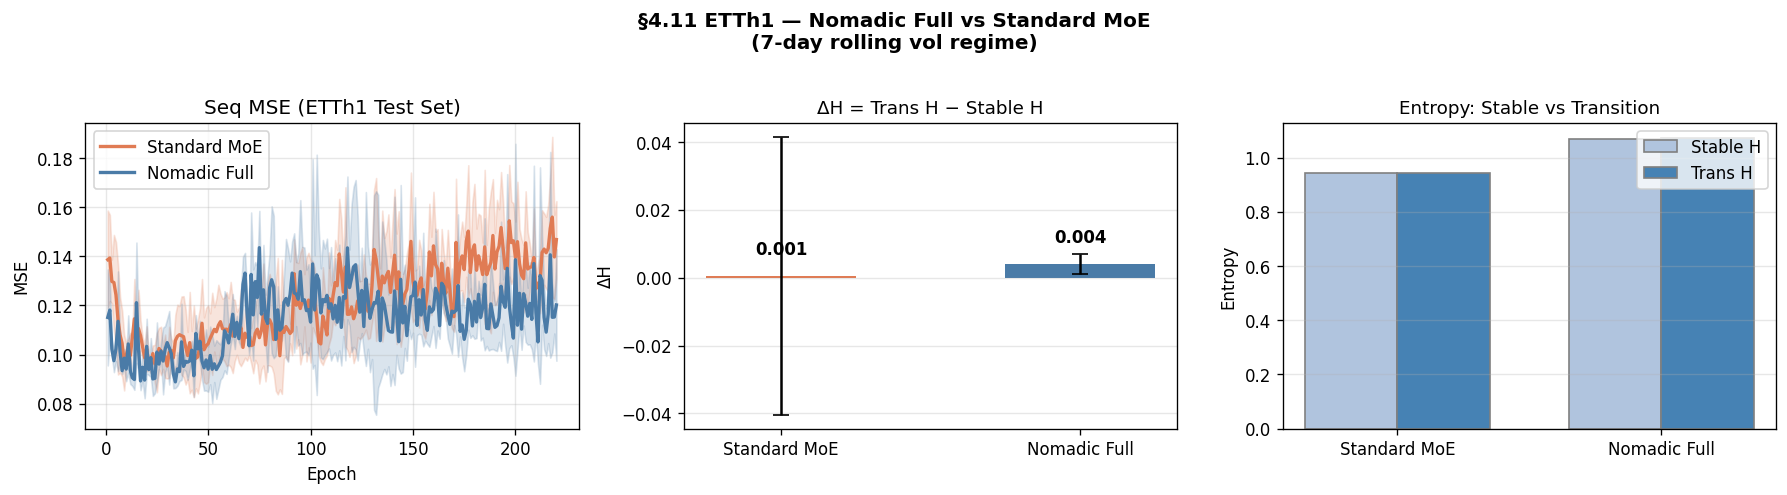

Plot saved.


In [12]:
# ============================================================
# STEP 11: 시각화
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors = {'StdMoE': '#E07B54', 'Nomadic_Full': '#4A7BA7'}

# (1) MSE 학습 곡선
ax = axes[0]
for variant in VARIANTS:
    mse_per_seed = [all_results[variant][s]['mse_log'] for s in SEEDS]
    mean_mse = np.mean(mse_per_seed, axis=0)
    std_mse  = np.std(mse_per_seed, axis=0)
    ep = range(1, len(mean_mse)+1)
    ax.plot(ep, mean_mse, label=labels[variant], color=colors[variant], linewidth=2)
    ax.fill_between(ep, mean_mse-std_mse, mean_mse+std_mse, alpha=0.2, color=colors[variant])
ax.set_title('Seq MSE (ETTh1 Test Set)', fontsize=12)
ax.set_xlabel('Epoch'); ax.set_ylabel('MSE')
ax.legend(); ax.grid(alpha=0.3)

# (2) ΔH bar
ax = axes[1]
dh_means, dh_stds = [], []
for variant in VARIANTS:
    dh_per_seed = []
    for seed in SEEDS:
        d = all_results[variant][seed]['dyn_log'][-1]
        dh_per_seed.append(d['transition_entropy_mean'] - d['stable_entropy_mean'])
    dh_means.append(np.nanmean(dh_per_seed))
    dh_stds.append(np.nanstd(dh_per_seed))
bars = ax.bar([labels[v] for v in VARIANTS], dh_means,
              color=[colors[v] for v in VARIANTS], yerr=dh_stds, capsize=5, width=0.5)
ax.set_title('ΔH = Trans H − Stable H', fontsize=11)
ax.set_ylabel('ΔH')
for bar, val in zip(bars, dh_means):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

# (3) Stable vs Trans Entropy
ax = axes[2]
x = np.arange(len(VARIANTS)); w = 0.35
sh_m = [np.nanmean([all_results[v][s]['dyn_log'][-1]['stable_entropy_mean']     for s in SEEDS]) for v in VARIANTS]
th_m = [np.nanmean([all_results[v][s]['dyn_log'][-1]['transition_entropy_mean'] for s in SEEDS]) for v in VARIANTS]
ax.bar(x-w/2, sh_m, w, label='Stable H',  color='#B0C4DE', edgecolor='gray')
ax.bar(x+w/2, th_m, w, label='Trans H',   color='#4682B4', edgecolor='gray')
ax.set_title('Entropy: Stable vs Transition', fontsize=11)
ax.set_ylabel('Entropy')
ax.set_xticks(x); ax.set_xticklabels([labels[v] for v in VARIANTS])
ax.legend(); ax.grid(axis='y', alpha=0.3)

plt.suptitle('§4.11 ETTh1 — Nomadic Full vs Standard MoE\n(7-day rolling vol regime)',
             fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(f'{Config().save_dir}/etth1_results.png', dpi=150, bbox_inches='tight')
plt.show()
print('Plot saved.')

In [13]:
# ============================================================
# STEP 12: PAPER.md 반영용 요약 출력
# ============================================================
print('\n' + '='*70)
print('§4.11 PAPER.md 반영용 마크다운 테이블')
print('='*70)

summary = {}
for variant in VARIANTS:
    mse_v, sh_v, th_v, dh_v, lat_v = [], [], [], [], []
    for seed in SEEDS:
        r = all_results[variant][seed]
        d = r['dyn_log'][-1]
        mse_v.append(r['mse_log'][-1])
        sh, th = d['stable_entropy_mean'], d['transition_entropy_mean']
        sh_v.append(sh); th_v.append(th)
        dh_v.append(th - sh if not (math.isnan(th) or math.isnan(sh)) else float('nan'))
        lat_v.append(d['mean_switch_latency'])
    summary[variant] = {
        'mse_mean': np.nanmean(mse_v), 'mse_std': np.nanstd(mse_v),
        'dh_mean':  np.nanmean(dh_v),  'dh_std':  np.nanstd(dh_v),
        'sh_mean':  np.nanmean(sh_v),  'th_mean':  np.nanmean(th_v),
        'lat_mean': np.nanmean(lat_v),
    }

print('\n| Model | Seq MSE | MSE std | ΔH | ΔH std | Stable H | Trans H | Switch Lat |')
print('|---|---|---|---|---|---|---|---|')
for variant in VARIANTS:
    s = summary[variant]
    lat_str = f"{s['lat_mean']:.3f}" if not math.isnan(s['lat_mean']) else '—'
    print(f"| {labels[variant]} | {s['mse_mean']:.3f} | {s['mse_std']:.3f} | "
          f"{s['dh_mean']:.3f} | {s['dh_std']:.3f} | "
          f"{s['sh_mean']:.3f} | {s['th_mean']:.3f} | {lat_str} |")

std_s = summary['StdMoE']
nom_s = summary['Nomadic_Full']
mse_delta = std_s['mse_mean'] - nom_s['mse_mean']
mse_rel   = mse_delta / std_s['mse_mean'] * 100

print()
print(f"MSE: StdMoE {std_s['mse_mean']:.4f} → Nomadic {nom_s['mse_mean']:.4f} "
      f"({'improvement' if mse_delta > 0 else 'degradation'}: {abs(mse_rel):.1f}%)")
if std_s['dh_mean'] > 0:
    print(f"ΔH ratio: Nomadic({nom_s['dh_mean']:.3f}) / StdMoE({std_s['dh_mean']:.3f}) "
          f"= {nom_s['dh_mean']/std_s['dh_mean']:.2f}×")
print(f"Stable H: StdMoE {std_s['sh_mean']:.4f} vs Nomadic {nom_s['sh_mean']:.4f} "
      f"({'fixation observed' if nom_s['sh_mean'] < std_s['sh_mean'] else 'fixation NOT observed'})")

print()
print('--- Bitcoin 비교 (방법론 일관성) ---')
print('Bitcoin: Nomadic Stable H=1.055, StdMoE Stable H=0.888 → fixation X')
print(f"ETTh1:   Nomadic Stable H={nom_s['sh_mean']:.3f}, StdMoE Stable H={std_s['sh_mean']:.3f}")
print('→ 두 실험 비교로 Nomadic의 작동 조건(stable run length)을 실증적으로 경계 설정 가능')


§4.11 PAPER.md 반영용 마크다운 테이블

| Model | Seq MSE | MSE std | ΔH | ΔH std | Stable H | Trans H | Switch Lat |
|---|---|---|---|---|---|---|---|
| Standard MoE | 0.147 | 0.016 | 0.001 | 0.041 | 0.943 | 0.943 | 2.385 |
| Nomadic Full | 0.120 | 0.023 | 0.004 | 0.003 | 1.070 | 1.074 | 1.867 |

MSE: StdMoE 0.1468 → Nomadic 0.1202 (improvement: 18.1%)
ΔH ratio: Nomadic(0.004) / StdMoE(0.001) = 7.36×
Stable H: StdMoE 0.9428 vs Nomadic 1.0697 (fixation NOT observed)

--- Bitcoin 비교 (방법론 일관성) ---
Bitcoin: Nomadic Stable H=1.055, StdMoE Stable H=0.888 → fixation X
ETTh1:   Nomadic Stable H=1.070, StdMoE Stable H=0.943
→ 두 실험 비교로 Nomadic의 작동 조건(stable run length)을 실증적으로 경계 설정 가능
